In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

In [29]:
# 1. Dados — portfólio com 4 ativos brasileiros
tickers = ["PETR4.SA", "VALE3.SA", "ITUB4.SA", "WEGE3.SA"]
portfolio_weights = np.array([0.30, 0.25, 0.25, 0.20])   # pesos do portfólio

close_prices = yf.download(tickers, start="2007-01-01", end="2026-01-01", auto_adjust=True)["Close"]
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

# retorno diário do portfólio
portfolio_log_returns = log_returns @ portfolio_weights
portfolio_log_returns.name = "portfólio"

print(f"Período: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print(f"Observações: {len(log_returns)}")
display(log_returns.describe().round(4))

[*********************100%***********************]  4 of 4 completed

Período: 2007-01-03 → 2025-12-30
Observações: 4715


Ticker,ITUB4.SA,PETR4.SA,VALE3.SA,WEGE3.SA
count,4715.0000,4715.0000,4715.0000,4715.0000
mean,0.0004,0.0004,0.0004,0.0008
std,0.0213,0.0279,0.0260,0.0215
min,-0.1980,-0.3524,-0.2818,-0.2309
25%,-0.0106,-0.0129,-0.0129,-0.0099
50%,0.0002,0.0006,0.0000,0.0000
75%,0.0113,0.0137,0.0133,0.0115
max,0.2100,0.2007,0.1936,0.2513


In [30]:
# 2. Stress Histórico — crises identificadas
#    Recortamos os piores períodos conhecidos e medimos o impacto real no portfólio

crisis_periods = {
    "Crise de 2008 (Lehman)"    : ("2008-09-01", "2009-03-31"),
    "Crise Europeia 2011"        : ("2011-07-01", "2011-12-31"),
    "Impeachment / Lava-Jato 2015": ("2015-01-01", "2016-01-31"),
    "COVID-19 2020"               : ("2020-02-01", "2020-04-30"),
    "Alta de juros EUA 2022"      : ("2022-01-01", "2022-12-31"),
}

crisis_rows = []
for crisis_name, (start_date, end_date) in crisis_periods.items():
    period_returns = portfolio_log_returns.loc[start_date:end_date]
    total_log_return = period_returns.sum()                            # retorno acumulado log
    annual_volatility = period_returns.std() * np.sqrt(252)
    worst_day = period_returns.min()
    crisis_rows.append({
        "Crise"              : crisis_name,
        "Volatilidade Anual" : f"{annual_volatility:.2%}",
        "Pior Dia"           : f"{worst_day:.2%}",
        "Dias Úteis"         : len(period_returns),
    })

crisis_summary = pd.DataFrame(crisis_rows).set_index("Crise")
display(crisis_summary)

,Volatilidade Anual,Pior Dia,Dias Úteis
Crise,,,
Crise de 2008 (Lehman),69.47%,-13.11%,145
Crise Europeia 2011,27.44%,-7.11%,126
Impeachment / Lava-Jato 2015,33.82%,-5.97%,265
COVID-19 2020,84.95%,-17.13%,60
Alta de juros EUA 2022,23.21%,-4.72%,250


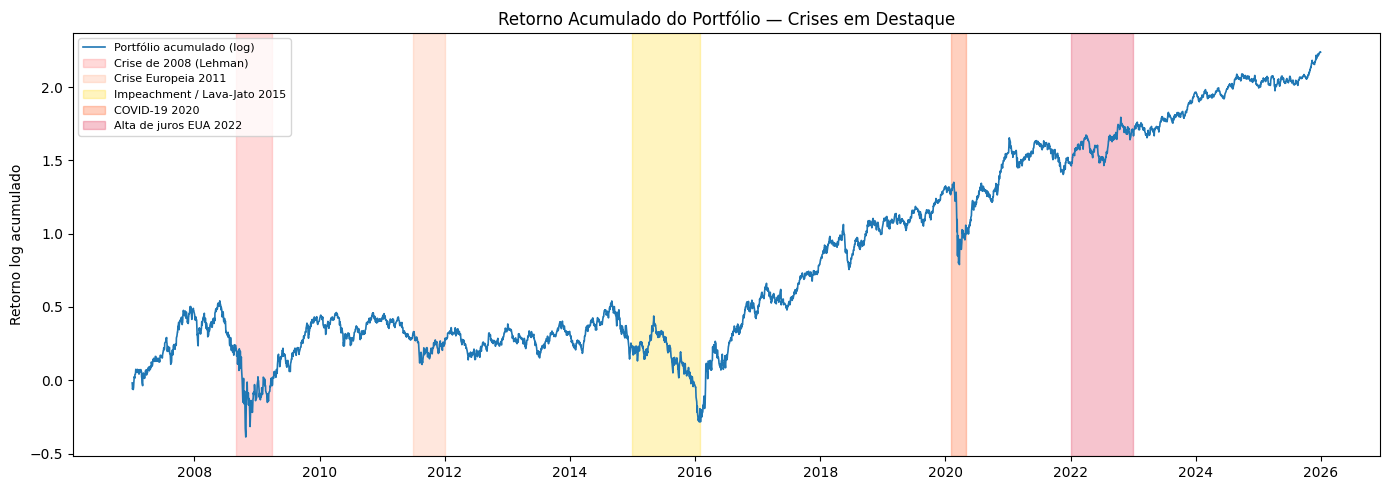

In [31]:
# 3. Visualização do portfólio acumulado com as crises destacadas

portfolio_log_cumulative = portfolio_log_returns.cumsum()   # retorno log acumulado (equivalente a ln(Pt/P0))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(portfolio_log_cumulative.index, portfolio_log_cumulative, lw=1.2, label="Portfólio acumulado (log)")

crisis_colors = ["#FF6B6B", "#FFA07A", "#FFD700", "#FF4500", "#DC143C"]
for (crisis_name, (start_date, end_date)), color in zip(crisis_periods.items(), crisis_colors):
    ax.axvspan(pd.Timestamp(start_date), pd.Timestamp(end_date), alpha=0.25, color=color, label=crisis_name)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Retorno Acumulado do Portfólio — Crises em Destaque")
ax.set_ylabel("Retorno log acumulado")
plt.tight_layout()
plt.show()

In [32]:
# 4. Análise de Cenários — choques manuais nos fatores
#    Definimos cenários hipotéticos aplicando um choque percentual em cada ativo
#    e calculamos o impacto no portfólio

scenarios = {
    "Base (sem choque)"          : {"PETR4.SA":  0.00, "VALE3.SA":  0.00, "ITUB4.SA":  0.00, "WEGE3.SA":  0.00},
    "Queda do petróleo (-30%)"   : {"PETR4.SA": -0.30, "VALE3.SA": -0.05, "ITUB4.SA": -0.03, "WEGE3.SA": -0.02},
    "Recessão global (-20% broad)": {"PETR4.SA": -0.20, "VALE3.SA": -0.25, "ITUB4.SA": -0.18, "WEGE3.SA": -0.15},
    "Alta de juros SELIC +5pp"   : {"PETR4.SA": -0.08, "VALE3.SA": -0.06, "ITUB4.SA":  0.05, "WEGE3.SA": -0.12},
    "Boom de commodities (+25%)" : {"PETR4.SA":  0.25, "VALE3.SA":  0.30, "ITUB4.SA":  0.05, "WEGE3.SA":  0.03},
    "Crise cambial BRL -20%"     : {"PETR4.SA":  0.15, "VALE3.SA":  0.18, "ITUB4.SA": -0.10, "WEGE3.SA":  0.10},
}

scenario_rows = []
for scenario_name, shocks_by_ticker in scenarios.items():
    shock_vector = np.array([shocks_by_ticker[t] for t in tickers])
    portfolio_impact = float(portfolio_weights @ shock_vector)             # impacto ponderado no portfólio
    scenario_rows.append({
        "Cenário"           : scenario_name,
        "PETR4"             : f"{shocks_by_ticker['PETR4.SA']:+.0%}",
        "VALE3"             : f"{shocks_by_ticker['VALE3.SA']:+.0%}",
        "ITUB4"             : f"{shocks_by_ticker['ITUB4.SA']:+.0%}",
        "WEGE3"             : f"{shocks_by_ticker['WEGE3.SA']:+.0%}",
        "Impacto Portfólio" : f"{portfolio_impact:+.2%}",
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("Cenário")
display(scenario_table)

,PETR4,VALE3,ITUB4,WEGE3,Impacto Portfólio
Cenário,,,,,
Base (sem choque),+0%,+0%,+0%,+0%,+0.00%
Queda do petróleo (-30%),-30%,-5%,-3%,-2%,-11.40%
Recessão global (-20% broad),-20%,-25%,-18%,-15%,-19.75%
Alta de juros SELIC +5pp,-8%,-6%,+5%,-12%,-5.05%
Boom de commodities (+25%),+25%,+30%,+5%,+3%,+16.85%
Crise cambial BRL -20%,+15%,+18%,-10%,+10%,+8.50%


In [33]:
# 5. Stress Test via Monte Carlo — simulação de N cenários extremos
#    Usamos a distribuição histórica (média e covariância) e geramos 10.000 cenários de 1 dia
#    Focamos no tail (5% piores) para stress

np.random.seed(42)
num_simulations = 10000
daily_mean = log_returns.mean().values
cov_matrix = log_returns.cov().values

# cholesky para gerar retornos correlacionados
cholesky_cov = np.linalg.cholesky(cov_matrix)
random_normals = np.random.standard_normal((num_simulations, len(tickers)))
simulated_asset_returns = random_normals @ cholesky_cov.T + daily_mean              # shape (num_simulations, 4)
simulated_portfolio_returns = simulated_asset_returns @ portfolio_weights           # retorno do portfólio em cada simulação

tail_alpha = 0.05
var_mc_95 = np.percentile(simulated_portfolio_returns, tail_alpha * 100)
cvar_mc_95 = simulated_portfolio_returns[simulated_portfolio_returns <= var_mc_95].mean()

print(f"Monte Carlo (10 000 simulações, 1 dia, confiança 95%)")
print(f"  VaR  MC: {var_mc_95:.4f}  ({var_mc_95:.2%})")
print(f"  CVaR MC: {cvar_mc_95:.4f}  ({cvar_mc_95:.2%})")

Monte Carlo (10 000 simulações, 1 dia, confiança 95%)
  VaR  MC: -0.0294  (-2.94%)
  CVaR MC: -0.0371  (-3.71%)


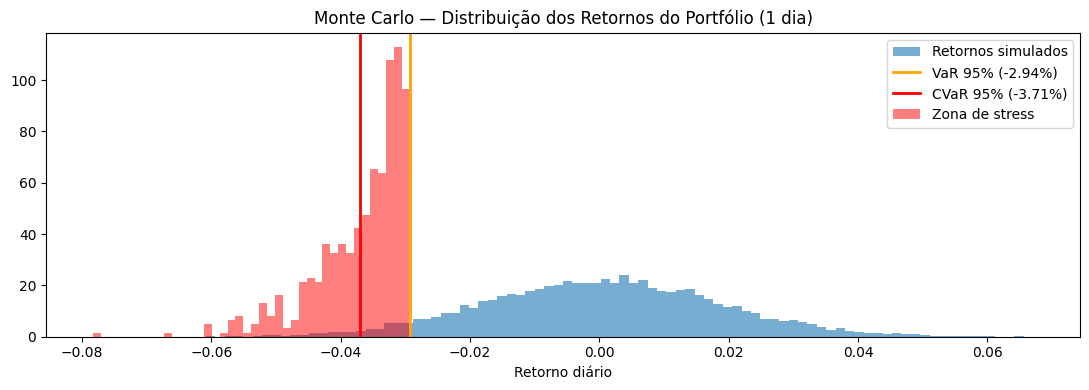

In [34]:
# 6. Distribuição dos retornos simulados com VaR e CVaR

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(simulated_portfolio_returns, bins=100, density=True, alpha=0.6, label="Retornos simulados")
ax.axvline(var_mc_95,  color="orange", lw=2, label=f"VaR 95% ({var_mc_95:.2%})")
ax.axvline(cvar_mc_95, color="red",    lw=2, label=f"CVaR 95% ({cvar_mc_95:.2%})")

# sombreia a região de stress (pior 5%)
stress_tail_returns = simulated_portfolio_returns[simulated_portfolio_returns <= var_mc_95]
ax.hist(stress_tail_returns, bins=40, density=True, alpha=0.5, color="red", label="Zona de stress")

ax.set_title("Monte Carlo — Distribuição dos Retornos do Portfólio (1 dia)")
ax.set_xlabel("Retorno diário")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# 7. Stress Test com choques na volatilidade (regime de alta volatilidade)
#    Multiplica a vol histórica por um fator de stress e re-simula

volatility_stress_factors = [1.0, 1.5, 2.0, 3.0]   # 1x = normal, 3x = crise severa
stress_rows = []

for factor in volatility_stress_factors:
    stress_cov = cov_matrix * (factor ** 2)          # escala variância
    stress_cholesky = np.linalg.cholesky(stress_cov)
    stress_simulated_portfolio_returns = (random_normals @ stress_cholesky.T + daily_mean) @ portfolio_weights
    var_stress_95 = np.percentile(stress_simulated_portfolio_returns, tail_alpha * 100)
    cvar_stress_95 = stress_simulated_portfolio_returns[stress_simulated_portfolio_returns <= var_stress_95].mean()
    stress_rows.append({
        "Fator de stress (vol)" : f"{factor:.1f}x",
        "VaR 95%"               : f"{var_stress_95:.2%}",
        "CVaR 95%"              : f"{cvar_stress_95:.2%}",
        "Perda 10 000 USD"      : f"${-cvar_stress_95 * 10_000:,.0f}",
    })

display(pd.DataFrame(stress_rows).set_index("Fator de stress (vol)"))

,VaR 95%,CVaR 95%,Perda 10 000 USD
Fator de stress (vol),,,
1.0x,-2.94%,-3.71%,$371
1.5x,-4.43%,-5.58%,$558
2.0x,-5.92%,-7.46%,$746
3.0x,-8.90%,-11.21%,"$1,121"
